<a href="https://colab.research.google.com/github/Harshit07-ux-dev/-Seasonal-Agriculture-Performance-Analysis/blob/main/Seasonal_Agriculture_Performance_Analysis_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [34]:
df = pd.read_csv('/content/seasonal_agriculture_performance_dataset.csv')

In [35]:
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [36]:
df.tail()


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.4,27.3,51.4,6.3,...,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.195,45.2
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.5,29.2,85.5,6.1,...,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.508,59.7
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.0,35.4,68.5,8.6,...,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.913,29.2
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.0,28.2,61.7,6.4,...,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.918,50.4
3999,SF14000,Punjab,Nashik,Wheat,Kharif,3.31,984.3,25.8,77.2,5.9,...,0.99,2.36,7.81,28812,263872,225022,-38850,1800,4.339,62.3


In [37]:
df.shape

(4000, 28)

In [38]:
df.columns

Index(['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares',
       'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct',
       'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha',
       'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method',
       'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score',
       'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne',
       'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3',
       'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct'],
      dtype='object')

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [40]:
df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,3952.000000,4000.00000,4000.000000,4000.000000,4000.000000,3960.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,3968.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,601.152657,26.81890,63.210500,7.323050,6.701010,26.508232,120.250825,57.781850,104.760050,...,0.826138,5.270595,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,288.925025,3.81818,11.960834,1.121186,0.641461,6.712484,31.216452,17.015074,27.742681,...,0.101747,13.361398,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,...,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,370.200000,23.90000,54.775000,6.600000,6.260000,21.700000,98.500000,46.200000,86.200000,...,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,582.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,...,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,834.950000,29.60000,71.900000,8.100000,7.140000,31.300000,141.225000,69.400000,123.600000,...,0.910000,2.840000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,...,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


In [41]:
df.isnull().sum()

,0
Farm_ID,0
State,0
District,0
Crop,0
Season,0
Farm_Area_Hectares,0
Rainfall_mm,48
Avg_Temperature_C,0
Humidity_pct,0
Sunlight_Hours_Day,0


In [42]:
# Inspect missing values and column data types
print("Missing Values per Column:")
print(df.isnull().sum()[df.isnull().sum() > 0])

print("\nDataset Summary Statistics:")
df.describe()

Missing Values per Column:
Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32
dtype: int64

Dataset Summary Statistics:


,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,3952.000000,4000.00000,4000.000000,4000.000000,4000.000000,3960.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,3968.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,601.152657,26.81890,63.210500,7.323050,6.701010,26.508232,120.250825,57.781850,104.760050,...,0.826138,5.270595,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,288.925025,3.81818,11.960834,1.121186,0.641461,6.712484,31.216452,17.015074,27.742681,...,0.101747,13.361398,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,...,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,370.200000,23.90000,54.775000,6.600000,6.260000,21.700000,98.500000,46.200000,86.200000,...,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,582.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,...,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,834.950000,29.60000,71.900000,8.100000,7.140000,31.300000,141.225000,69.400000,123.600000,...,0.910000,2.840000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,...,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


In [43]:
#  Clean data by filling missing values with median values based on groups
df['Rainfall_mm'] = df['Rainfall_mm'].fillna(df.groupby('Season')['Rainfall_mm'].transform('median'))
df['Soil_Moisture_pct'] = df['Soil_Moisture_pct'].fillna(df.groupby('Season')['Soil_Moisture_pct'].transform('median'))
df['Yield_Tonnes_Ha'] = df['Yield_Tonnes_Ha'].fillna(df.groupby('Crop')['Yield_Tonnes_Ha'].transform('median'))

# Verify zero missing values remain
print("Total Missing Values Remaining:", df.isnull().sum().sum())

Total Missing Values Remaining: 0


In [44]:
#  Calculate aggregated performance metrics by Season
seasonal_summary = df.groupby('Season').agg(
    Avg_Yield=('Yield_Tonnes_Ha', 'mean'),
    Avg_Rainfall=('Rainfall_mm', 'mean'),
    Avg_Temperature=('Avg_Temperature_C', 'mean'),
    Avg_Humidity=('Humidity_pct', 'mean'),
    Avg_Profit_INR=('Profit_INR', 'mean'),
    Avg_Water_Efficiency=('Water_Efficiency_t_per_1000m3', 'mean'),
    Avg_Disease_Risk=('Disease_Pest_Risk_pct', 'mean')
).reset_index()

# Display summary table
seasonal_summary

,Season,Avg_Yield,Avg_Rainfall,Avg_Temperature,Avg_Humidity,Avg_Profit_INR,Avg_Water_Efficiency,Avg_Disease_Risk
0,Kharif,5.629525,852.112676,28.454019,71.812591,178914.647555,5.891834,54.467903
1,Rabi,5.098731,435.937062,23.489183,57.893178,87689.470191,5.186122,40.482114
2,Zaid,4.640387,299.123232,31.042088,52.012121,-24804.824916,4.413239,38.216667


/tmp/ipykernel_718/2782811706.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Season', y='Profit_INR', estimator=np.mean, errorbar=None, palette='viridis')


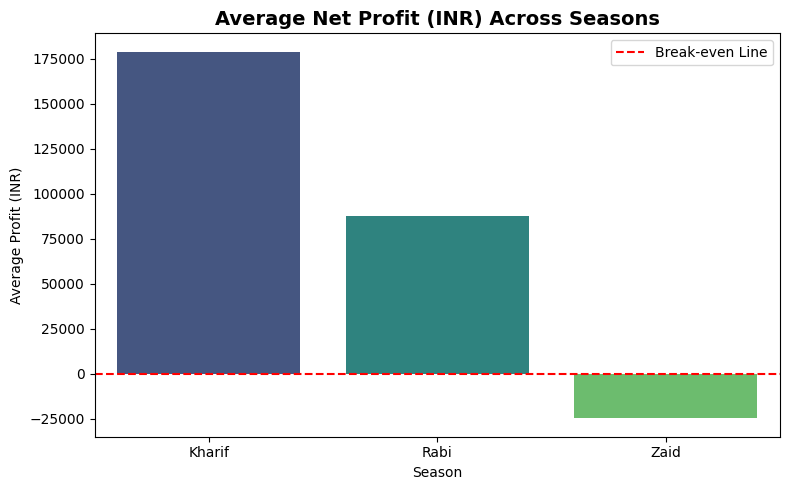

In [45]:
#  Plot average financial profit across seasons
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='Season', y='Profit_INR', estimator=np.mean, errorbar=None, palette='viridis')
plt.title('Average Net Profit (INR) Across Seasons', fontsize=14, fontweight='bold')
plt.xlabel('Season')
plt.ylabel('Average Profit (INR)')
plt.axhline(0, color='red', linestyle='--', label='Break-even Line')
plt.legend()
plt.tight_layout()
plt.show()

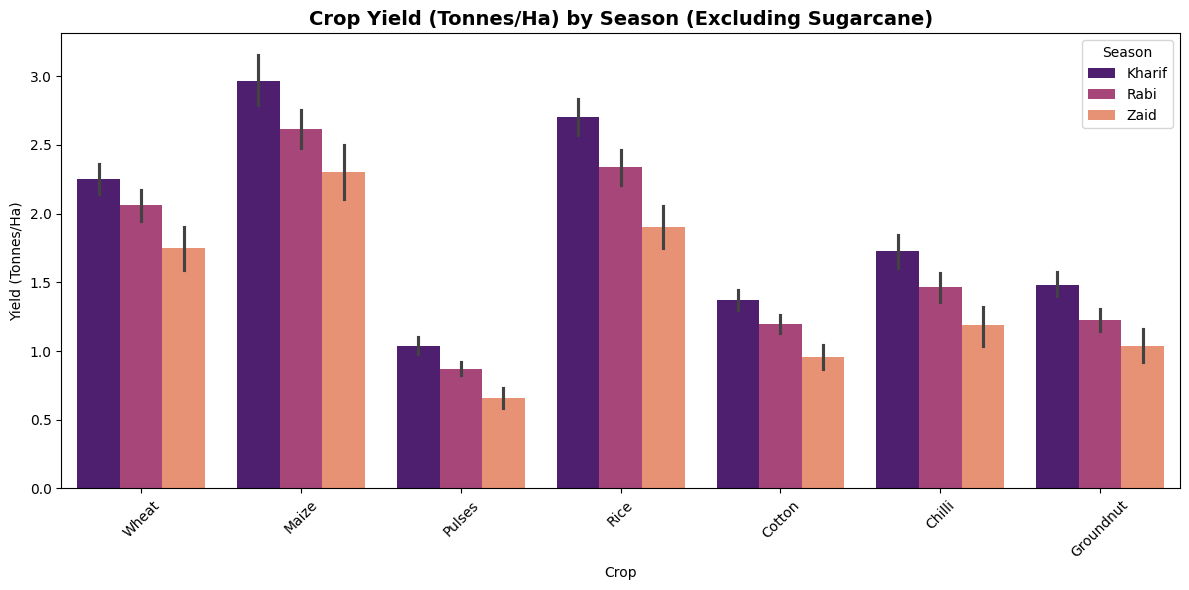

In [46]:
#  Plot yield breakdown by crop and season (excluding Sugarcane for visual clarity)
plt.figure(figsize=(12, 6))
df_filtered = df[df['Crop'] != 'Sugarcane']

sns.barplot(data=df_filtered, x='Crop', y='Yield_Tonnes_Ha', hue='Season', palette='magma')
plt.title('Crop Yield (Tonnes/Ha) by Season (Excluding Sugarcane)', fontsize=14, fontweight='bold')
plt.xlabel('Crop')
plt.ylabel('Yield (Tonnes/Ha)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

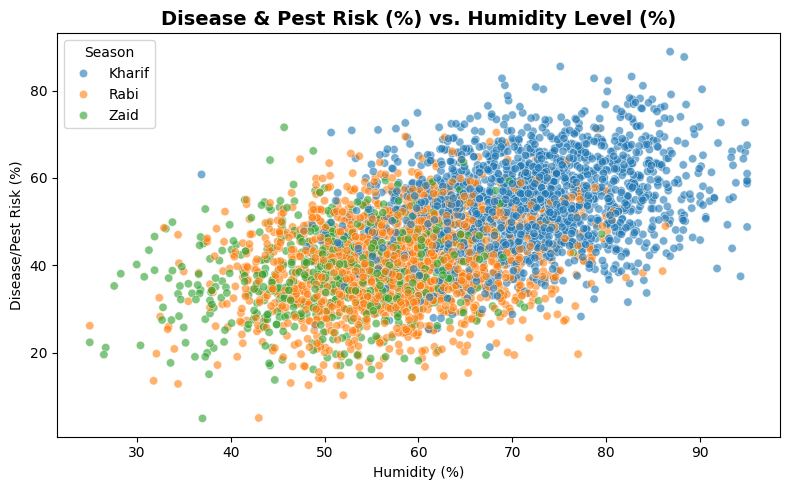

In [47]:
#  Plot humidity levels against pest and disease risk percentage
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Humidity_pct', y='Disease_Pest_Risk_pct', hue='Season', alpha=0.6)
plt.title('Disease & Pest Risk (%) vs. Humidity Level (%)', fontsize=14, fontweight='bold')
plt.xlabel('Humidity (%)')
plt.ylabel('Disease/Pest Risk (%)')
plt.tight_layout()
plt.show()

In [62]:
# IQR-based outlier summary for numerical columns

numeric_columns = df.select_dtypes(include=np.number).columns.tolist()
outlier_summary = []

for col in numeric_columns:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    count = ((df[col] < lower) | (df[col] > upper)).sum()

    outlier_summary.append({
        "Column": col,
        "Lower_Bound": lower,
        "Upper_Bound": upper,
        "Outlier_Count": count,
        "Outlier_Percentage": round(count / len(df) * 100, 2)
    })

outlier_summary = pd.DataFrame(outlier_summary).sort_values(
    "Outlier_Count", ascending=False
)

outlier_summary

,Column,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_Percentage
18,Profit_INR,-696111.000000,7.635670e+05,404,10.10
14,Production_Tonnes,-23.982500,5.335750e+01,333,8.33
20,Water_Efficiency_t_per_1000m3,-3.572875,1.038412e+01,322,8.05
13,Yield_Tonnes_Ha,-1.635000,5.525000e+00,304,7.60
19,Water_Used_m3,-6072.750000,1.617125e+04,276,6.90
17,Revenue_INR,-736519.000000,1.780911e+06,240,6.00
9,Potassium_kg_ha,30.100000,1.797000e+02,32,0.80
4,Sunlight_Hours_Day,4.350000,1.035000e+01,26,0.65
8,Phosphorus_kg_ha,11.400000,1.042000e+02,16,0.40
10,Fertilizer_kg_ha,19.137500,3.520375e+02,15,0.38


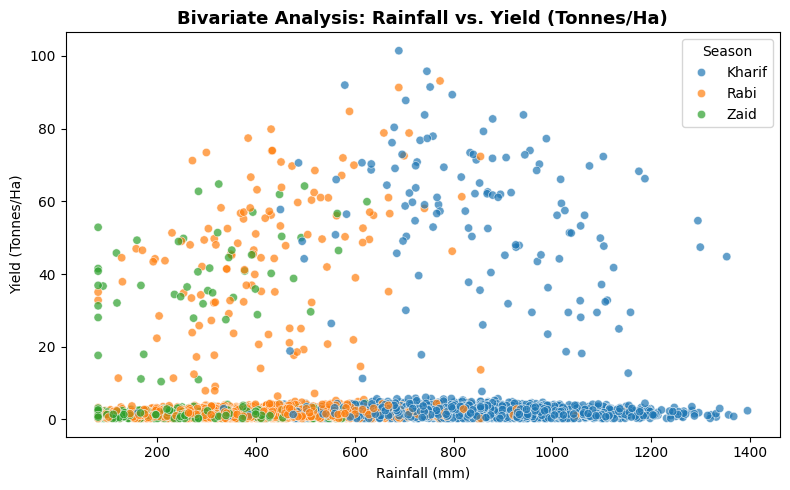

In [48]:
# Bivariate Analysis
#Rainfall vs. Crop Yield
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Rainfall_mm', y='Yield_Tonnes_Ha', hue='Season', alpha=0.7)
plt.title('Bivariate Analysis: Rainfall vs. Yield (Tonnes/Ha)', fontsize=13, fontweight='bold')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Yield (Tonnes/Ha)')
plt.tight_layout()
plt.show()

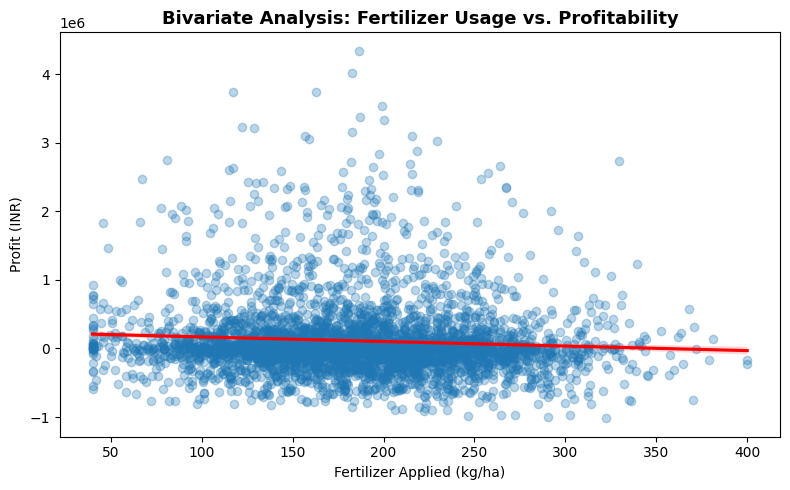

In [49]:
# Regression plot showing fertilizer impact on net profit
plt.figure(figsize=(8, 5))
sns.regplot(data=df, x='Fertilizer_kg_ha', y='Profit_INR', scatter_kws={'alpha': 0.3}, line_kws={'color': 'red'})
plt.title('Bivariate Analysis: Fertilizer Usage vs. Profitability', fontsize=13, fontweight='bold')
plt.xlabel('Fertilizer Applied (kg/ha)')
plt.ylabel('Profit (INR)')
plt.tight_layout()
plt.show()

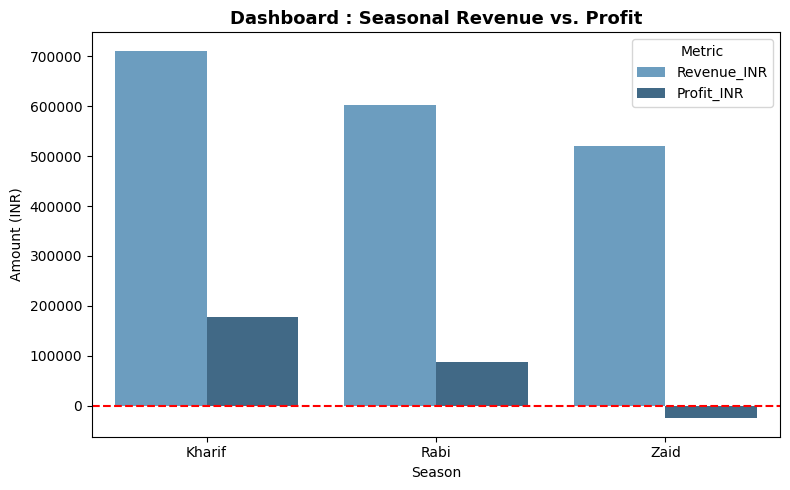

In [50]:
# Plot seasonal revenue vs profit breakdown
profit_rev = df.groupby('Season')[['Revenue_INR', 'Profit_INR']].mean().reset_index()
profit_rev_melted = profit_rev.melt(id_vars='Season', value_vars=['Revenue_INR', 'Profit_INR'],
                                     var_name='Metric', value_name='Amount_INR')

plt.figure(figsize=(8, 5))
sns.barplot(data=profit_rev_melted, x='Season', y='Amount_INR', hue='Metric', palette='Blues_d')
plt.title('Dashboard : Seasonal Revenue vs. Profit', fontsize=13, fontweight='bold')
plt.ylabel('Amount (INR)')
plt.axhline(0, color='red', linestyle='--')
plt.tight_layout()
plt.show()

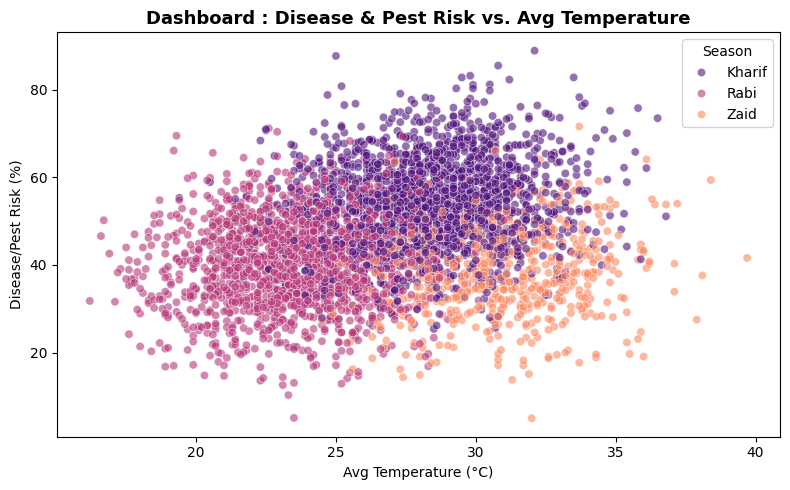

In [51]:
# Scatter plot of temperature vs disease risk across seasons
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Avg_Temperature_C', y='Disease_Pest_Risk_pct', hue='Season', palette='magma', alpha=0.6)
plt.title('Dashboard : Disease & Pest Risk vs. Avg Temperature', fontsize=13, fontweight='bold')
plt.xlabel('Avg Temperature (°C)')
plt.ylabel('Disease/Pest Risk (%)')
plt.tight_layout()
plt.show()

/tmp/ipykernel_718/2911716900.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_crops, x='Profit_INR', y='Crop', palette='viridis')


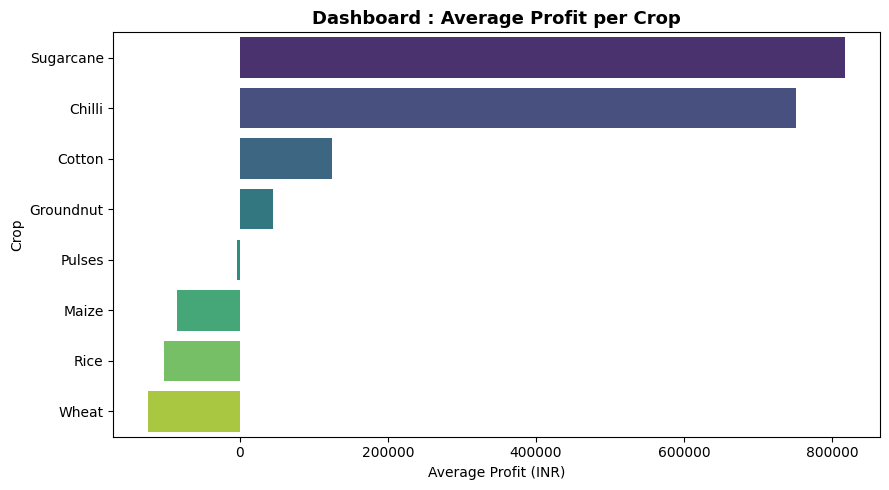

In [52]:
# Bar chart ranking profit by crop type
plt.figure(figsize=(9, 5))
top_crops = df.groupby('Crop')['Profit_INR'].mean().sort_values(ascending=False).reset_index()
sns.barplot(data=top_crops, x='Profit_INR', y='Crop', palette='viridis')
plt.title('Dashboard : Average Profit per Crop', fontsize=13, fontweight='bold')
plt.xlabel('Average Profit (INR)')
plt.tight_layout()
plt.show()

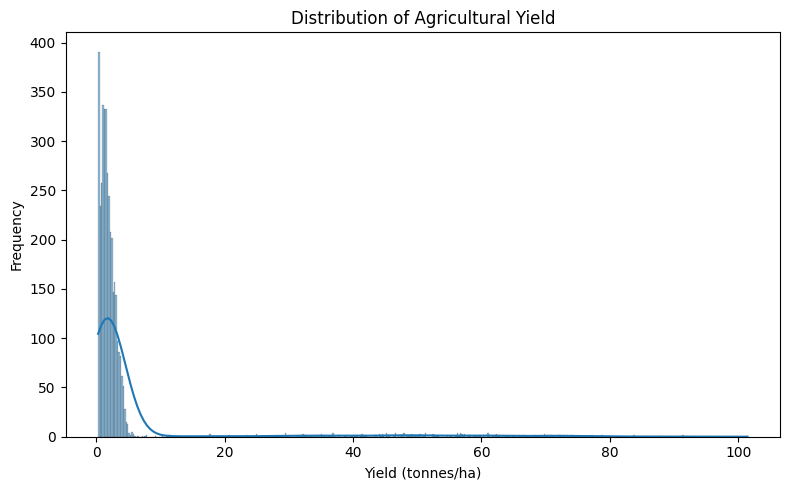

In [53]:

# Univariate: Yield distribution

plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="Yield_Tonnes_Ha", kde=True)
plt.title("Distribution of Agricultural Yield")
plt.xlabel("Yield (tonnes/ha)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

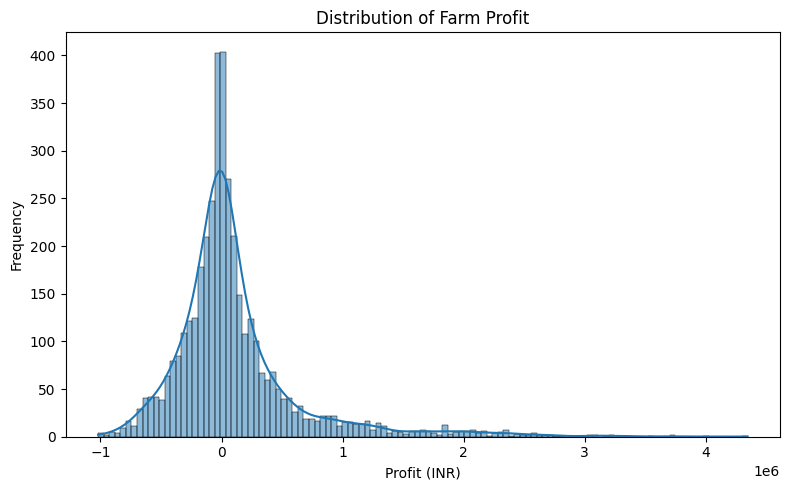

In [54]:
# Univariate: Profit distribution

plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="Profit_INR", kde=True)
plt.title("Distribution of Farm Profit")
plt.xlabel("Profit (INR)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

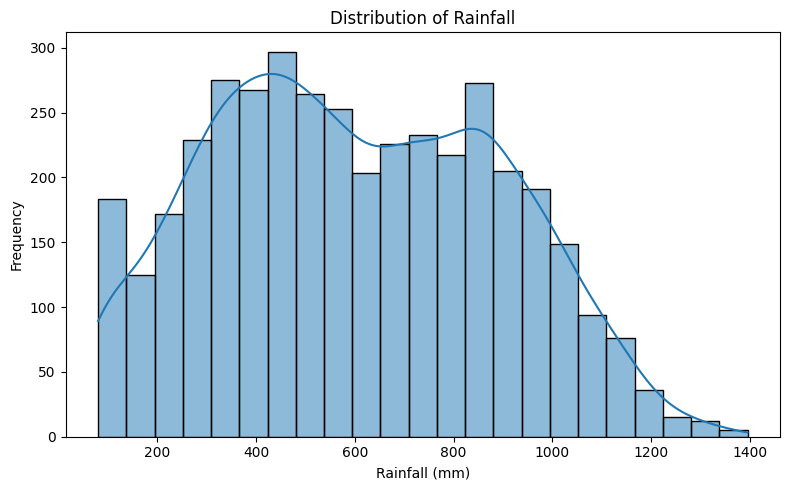

In [55]:

# Univariate: Rainfall distribution

plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="Rainfall_mm", kde=True)
plt.title("Distribution of Rainfall")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

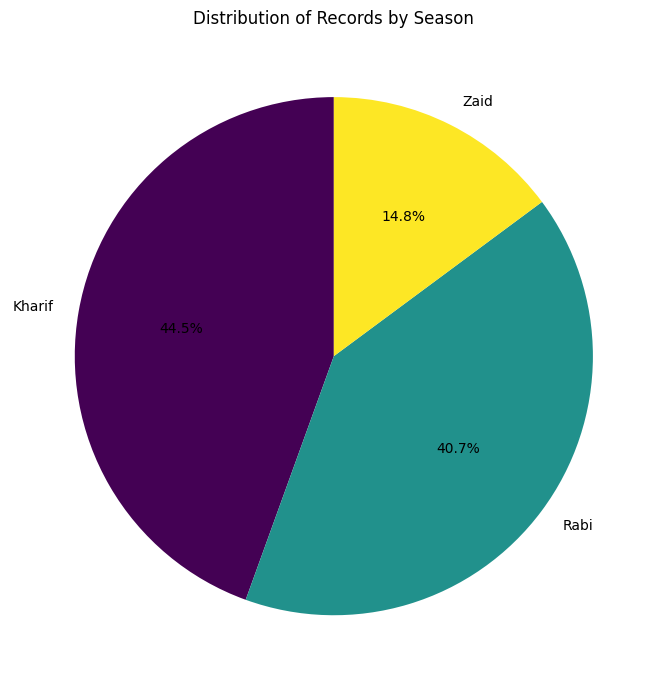

In [58]:

plt.figure(figsize=(7, 7))
df['Season'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, cmap='viridis')
plt.title('Distribution of Records by Season')
plt.ylabel('') # Hide the default 'Season' label on the y-axis
plt.tight_layout()
plt.show()

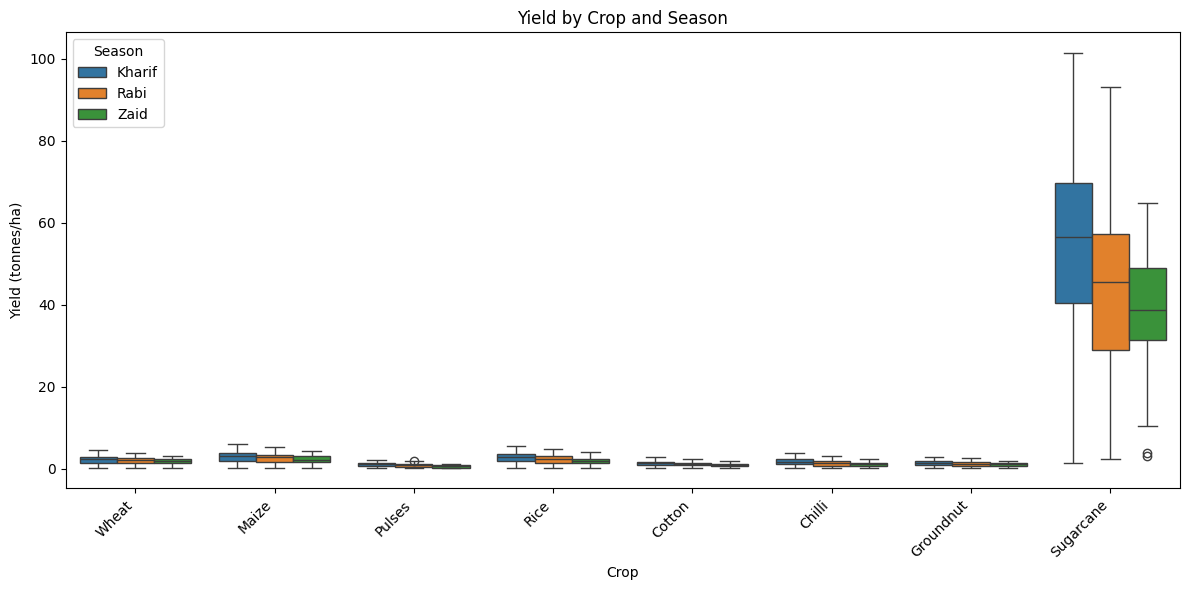

In [63]:

# Multivariate: Season, crop and yield

plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="Crop", y="Yield_Tonnes_Ha", hue="Season")
plt.xticks(rotation=45, ha="right")
plt.title("Yield by Crop and Season")
plt.xlabel("Crop")
plt.ylabel("Yield (tonnes/ha)")
plt.legend(title="Season")
plt.tight_layout()
plt.show()

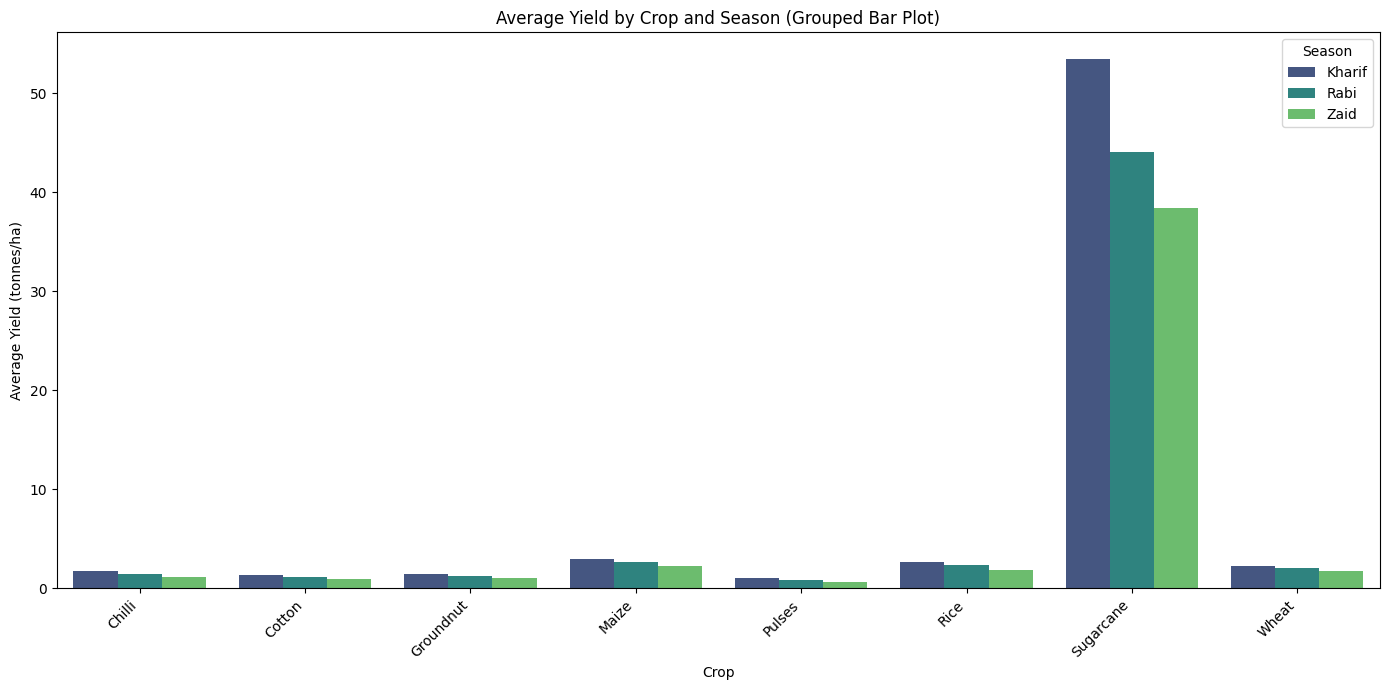

In [66]:
# Calculate average yield by crop and season
crop_season_summary = df.groupby(['Crop', 'Season'])['Yield_Tonnes_Ha'].mean().reset_index(name='Average_Yield')

plt.figure(figsize=(14, 7))
sns.barplot(data=crop_season_summary, x='Crop', y='Average_Yield', hue='Season', palette='viridis')
plt.title('Average Yield by Crop and Season (Grouped Bar Plot)')
plt.xlabel('Crop')
plt.ylabel('Average Yield (tonnes/ha)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Season')
plt.tight_layout()
plt.show()

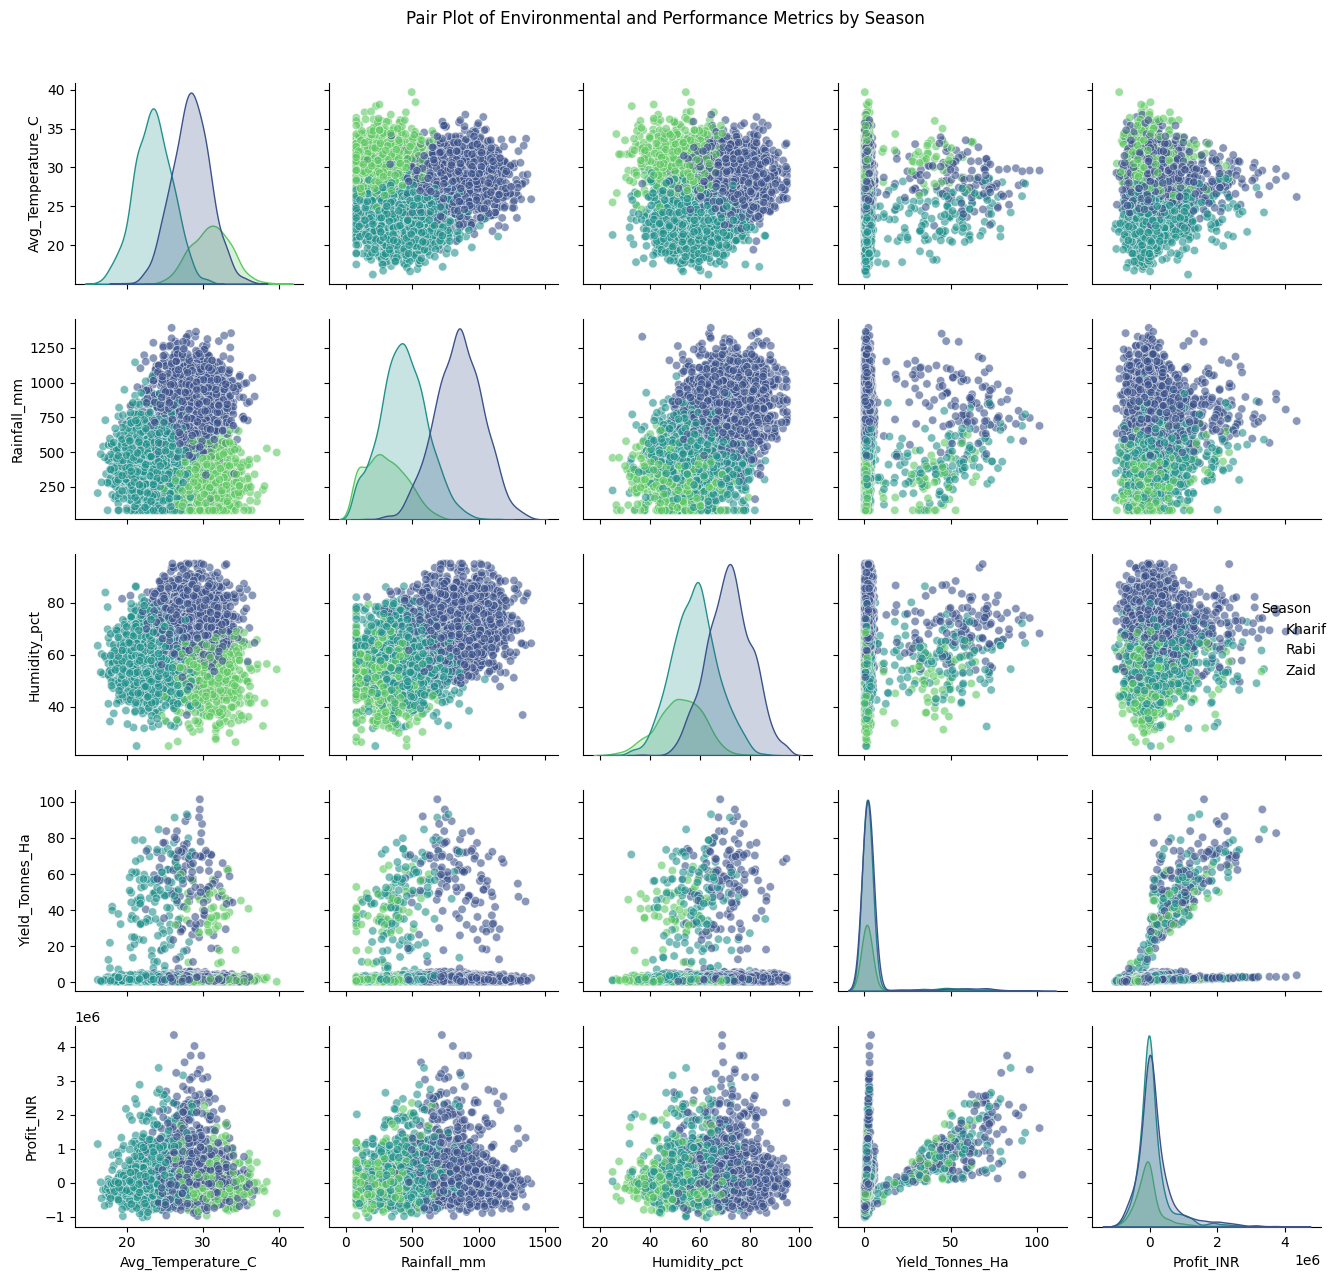

In [65]:

selected_columns = ['Avg_Temperature_C', 'Rainfall_mm', 'Humidity_pct', 'Yield_Tonnes_Ha', 'Profit_INR', 'Season']
sns.pairplot(df[selected_columns], hue='Season', palette='viridis', plot_kws={'alpha': 0.6})
plt.suptitle('Pair Plot of Environmental and Performance Metrics by Season', y=1.02) # Adjust suptitle position
plt.tight_layout()
plt.show()


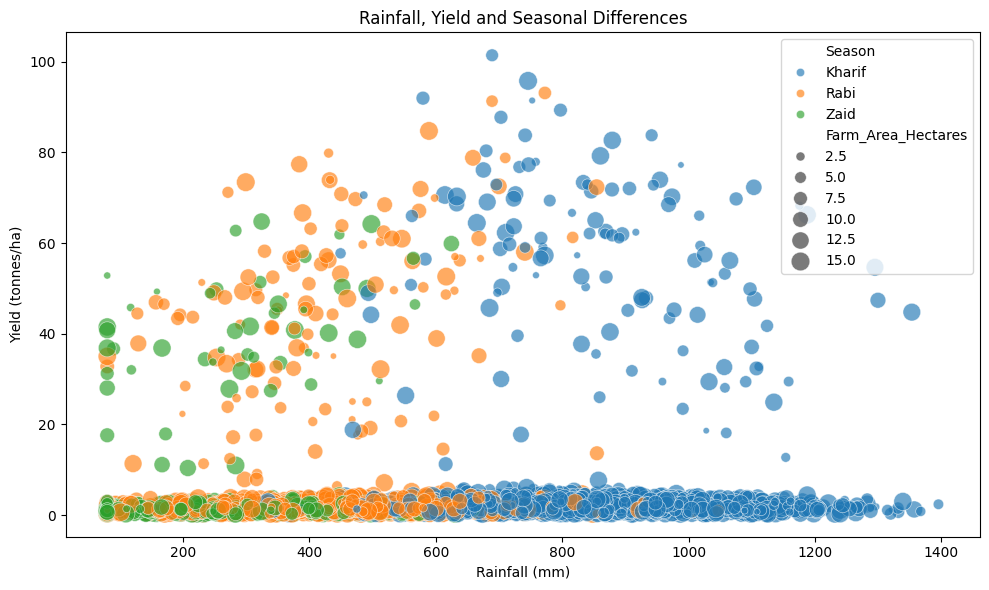

In [67]:

# Multivariate: Rainfall, yield and season

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x="Rainfall_mm",
    y="Yield_Tonnes_Ha",
    hue="Season",
    size="Farm_Area_Hectares",
    sizes=(20, 180),
    alpha=0.65
)
plt.title("Rainfall, Yield and Seasonal Differences")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (tonnes/ha)")
plt.tight_layout()
plt.show()


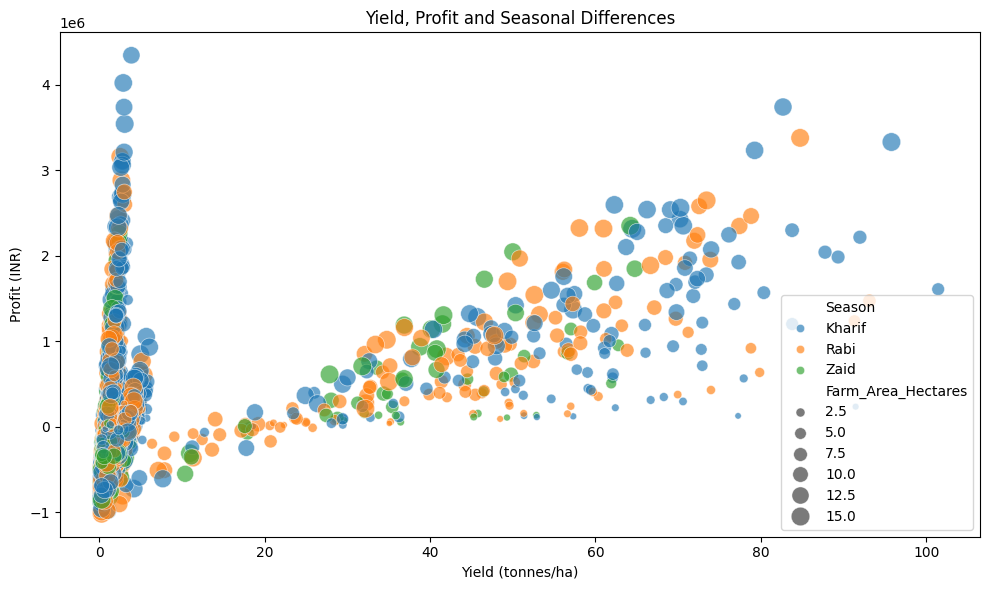

In [68]:

# Multivariate: Profit, yield and season

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x="Yield_Tonnes_Ha",
    y="Profit_INR",
    hue="Season",
    size="Farm_Area_Hectares",
    sizes=(20, 180),
    alpha=0.65
)
plt.title("Yield, Profit and Seasonal Differences")
plt.xlabel("Yield (tonnes/ha)")
plt.ylabel("Profit (INR)")
plt.tight_layout()
plt.show()

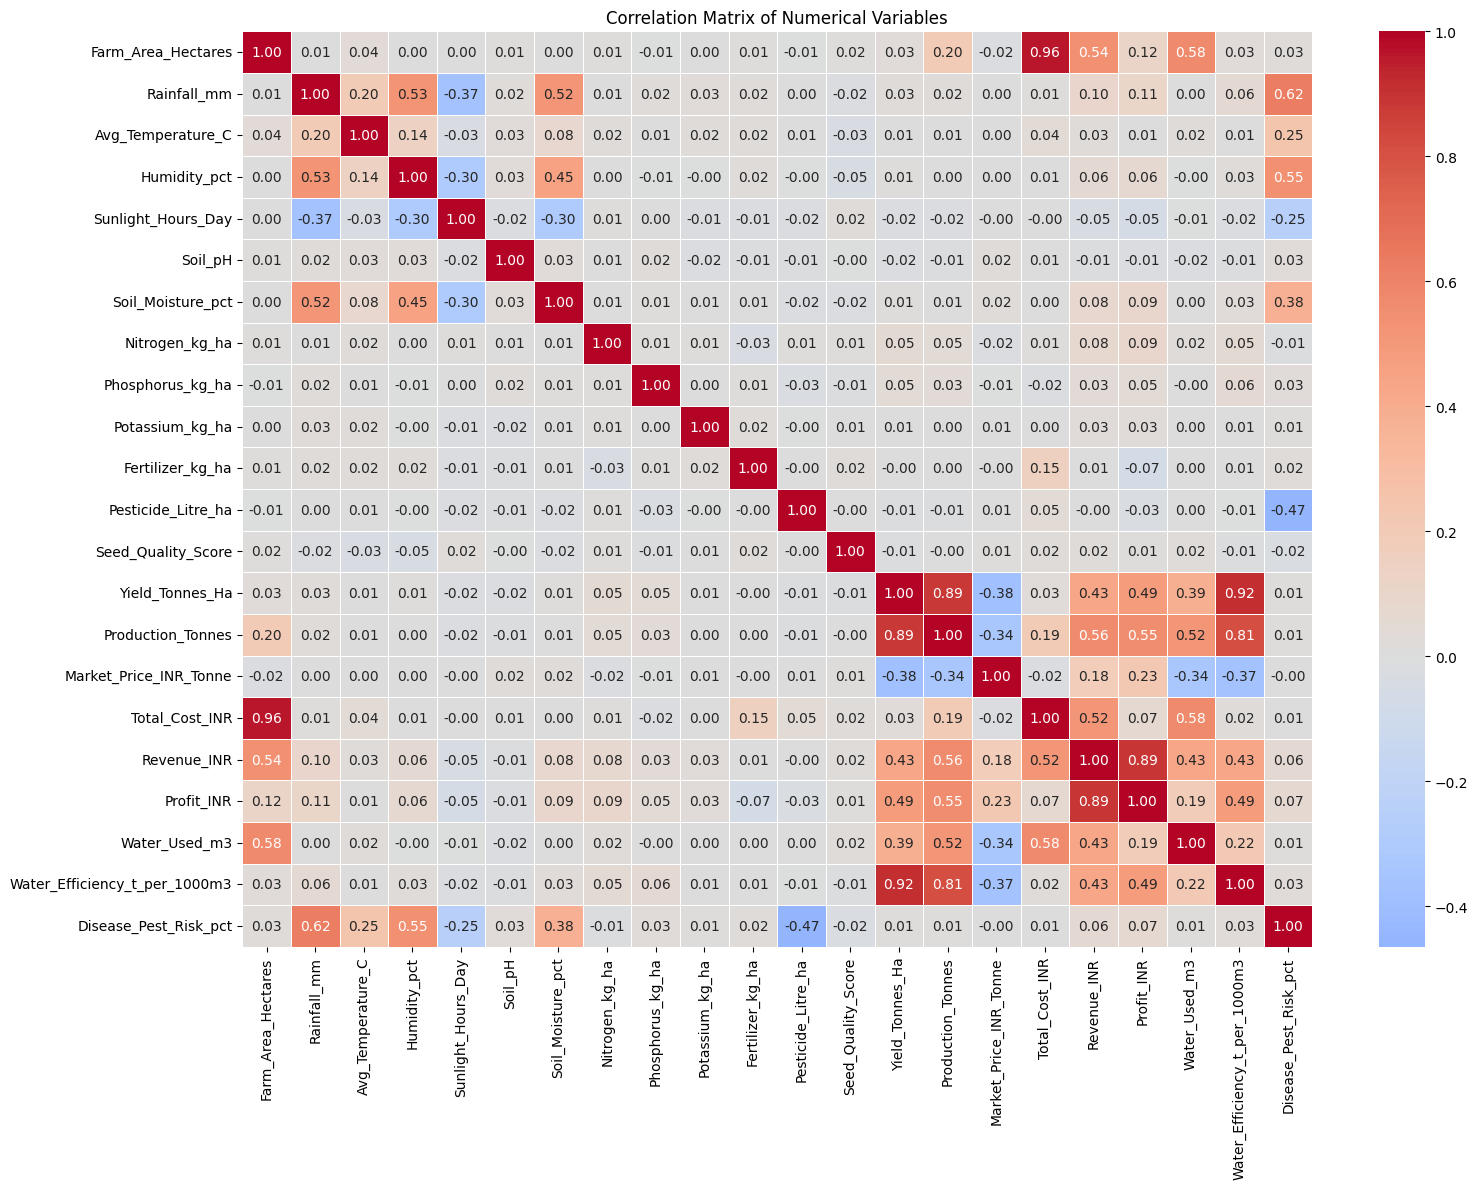

In [69]:

# Correlation heatmap for numerical variables

plt.figure(figsize=(16, 12))
corr = df[numeric_columns].corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Matrix of Numerical Variables")
plt.tight_layout()
plt.show()

In [70]:

#  seasonal summary

season_metrics = df.groupby("Season").agg(
    Records=("Farm_ID", "count"),
    Average_Yield=("Yield_Tonnes_Ha", "mean"),
    Total_Production=("Production_Tonnes", "sum"),
    Average_Profit=("Profit_INR", "mean"),
    Total_Profit=("Profit_INR", "sum"),
    Average_Water_Used=("Water_Used_m3", "mean")
).round(2)

season_metrics


,Records,Average_Yield,Total_Production,Average_Profit,Total_Profit,Average_Water_Used
Season,,,,,,
Kharif,1779,5.63,82387.61,178914.65,318289158,6102.20
Rabi,1627,5.10,67498.88,87689.47,142670768,5846.99
Zaid,594,4.64,23098.35,-24804.82,-14734066,6419.89


In [71]:

# Compare crop performance within each season

crop_season_summary = (
    df.groupby(["Season", "Crop"])
      .agg(
          Average_Yield=("Yield_Tonnes_Ha", "mean"),
          Average_Profit=("Profit_INR", "mean"),
          Average_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean")
      )
      .round(2)
      .sort_values(["Season", "Average_Yield"], ascending=[True, False])
)

crop_season_summary

Average_Yield  Average_Profit  Average_Water_Efficiency
Season Crop                                                              
Kharif Sugarcane          53.46      1000790.81                     36.00
       Maize               2.97       -39332.67                      6.05
       Rice                2.71       -64903.40                      2.17
       Wheat               2.26      -105871.87                      4.76
       Chilli              1.73       954380.42                      3.26
       Groundnut           1.48       108265.44                      3.58
       Cotton              1.37       216999.55                      2.13
       Pulses              1.04        43338.90                      3.35
Rabi   Sugarcane          44.00       731612.86                     27.92
       Maize               2.62       -89133.40                      5.46
       Rice                2.34       -98427.87                      1.84
       Wheat               2.06      -119954.57                      4.69
       Chilli              1.46       638572.50                      2.89
       Groundnut           1.23        10416.54                      2.90
       Cotton              1.19       107343.59                      1.94
       Pulses              0.87       -14309.14                      2.70
Zaid   Sugarcane          38.42       583635.80                     23.39
       Maize               2.30      -194049.17                      4.75
       Rice                1.90      -227239.34                      1.53
       Wheat               1.75      -193208.95                      4.02
       Chilli              1.19       448659.09                      2.20
       Groundnut           1.04       -68872.50                      2.47
       Cotton              0.95       -53925.34                      1.49
       Pulses              0.66      -139227.81                      1.95

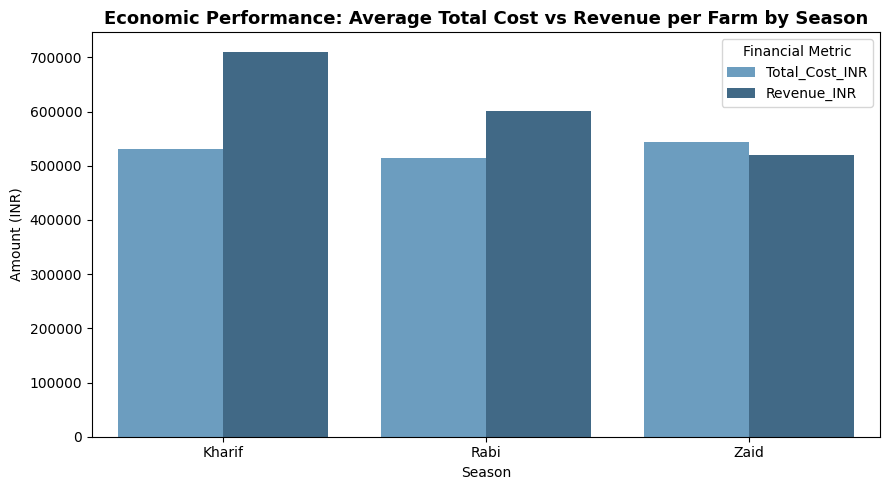

In [72]:
#Total Cost vs Revenue Comparison across Seasons
plt.figure(figsize=(9, 5))
cost_rev = df.groupby('Season')[['Total_Cost_INR', 'Revenue_INR']].mean().reset_index()
cost_rev_melted = cost_rev.melt(id_vars='Season', value_vars=['Total_Cost_INR', 'Revenue_INR'],
                                var_name='Financial Metric', value_name='Amount_INR')

sns.barplot(data=cost_rev_melted, x='Season', y='Amount_INR', hue='Financial Metric', palette='Blues_d')
plt.title('Economic Performance: Average Total Cost vs Revenue per Farm by Season', fontsize=13, fontweight='bold')
plt.xlabel('Season')
plt.ylabel('Amount (INR)')
plt.tight_layout()
plt.show()

/tmp/ipykernel_718/2283304972.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Season', y='ROI_pct', palette='Set2')


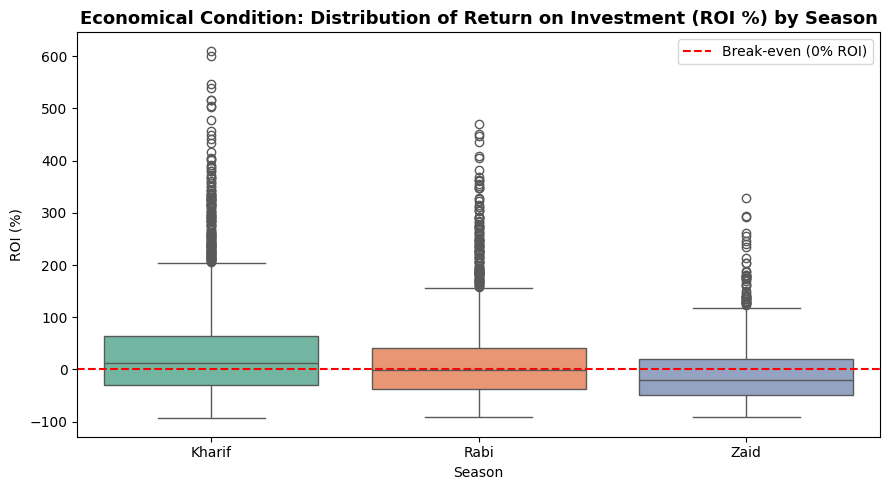

In [73]:
#  Return on Investment (ROI %) Analysis
df['ROI_pct'] = (df['Profit_INR'] / df['Total_Cost_INR']) * 100

plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x='Season', y='ROI_pct', palette='Set2')
plt.axhline(0, color='red', linestyle='--', label='Break-even (0% ROI)')
plt.title('Economical Condition: Distribution of Return on Investment (ROI %) by Season', fontsize=13, fontweight='bold')
plt.xlabel('Season')
plt.ylabel('ROI (%)')
plt.legend()
plt.tight_layout()
plt.show()

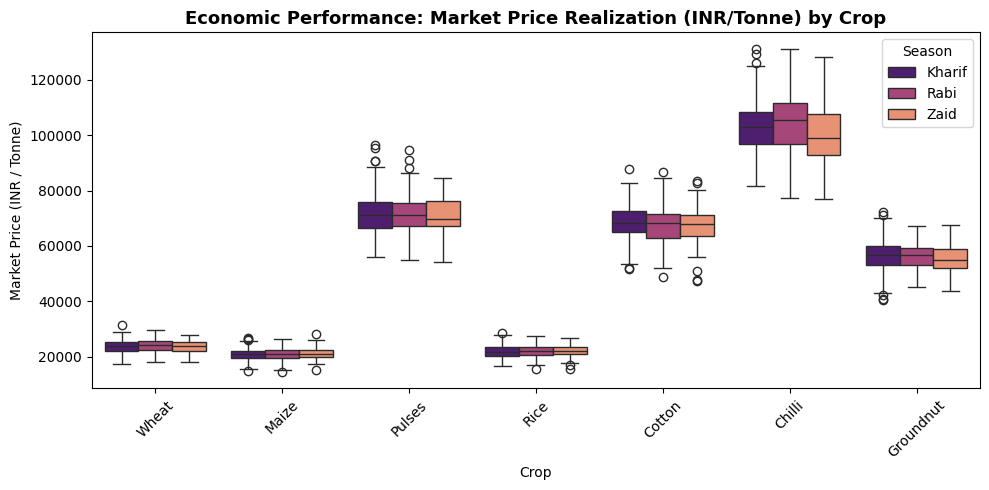

In [74]:
# Market Price Variation across Crops and Seasons
plt.figure(figsize=(10, 5))
sns.boxplot(data=df[df['Crop'] != 'Sugarcane'], x='Crop', y='Market_Price_INR_Tonne', hue='Season', palette='magma')
plt.title('Economic Performance: Market Price Realization (INR/Tonne) by Crop', fontsize=13, fontweight='bold')
plt.xlabel('Crop')
plt.ylabel('Market Price (INR / Tonne)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()